In [5]:
import os
import pandas as pd
import numpy as np

import seaborn as sns

In [6]:


import matplotlib.patches as mpatches


In [7]:
import copy
#CHANGE BOTH COL CATEGORIES AND REMOVE COLUMNS IF ANY CHANGE IS MADE IN THE COLUMNS 

col_categories={
    "climate_cols" : [
    'Kathmandu_Rainfall_MM', 
    'Hilly_Temperature', 'Hilly_Rainfall_MM', 
    'Sarlahi_Temperature', 'Sarlahi_Rainfall_MM'
    ],


    "economic_cols" : [
        'USD_TO_NPR', 'Diesel', 'Inflation'
    ],

    "market_cols" : [
        'Supply_Volume'
    ],

    "temporal_cols" : [
        'is_festival', 'Season_Autumn', 'Season_Monsoon', 'Season_Spring', 'Season_Winter',
        'is_weekend', 'month_sin', 'month_cos' # some features are not engineered yet but these are final feature set for base
    ]
}

col_categories_no_lag = copy.deepcopy(col_categories)

In [8]:
remove_cols = [
    'imported_tomato_price', 'Dhading_Wind_Speed', 'Dhading_Temperature',
    'Dhading_Precipitation', 'Dhading_Rainfall_MM', 'Dhading_Air_Pressure',
    'Kathmandu_Wind_Speed', 'Kathmandu_Precipitation', 'Kathmandu_Air_Pressure',
    'Kavre_Wind_Speed', 'Kavre_Temperature', 'Kavre_Precipitation',
    'Kavre_Rainfall_MM', 'Kavre_Air_Pressure',
    'Sarlahi_Wind_Speed', 'Sarlahi_Precipitation', 'Sarlahi_Air_Pressure',
    'Hilly_Precipitation', 'Hilly_Wind_Speed', 'Hilly_Air_Pressure'
]


In [9]:
np.random.seed(42)

# Create directories for saving artifacts
os.makedirs("artifacts/eda_images", exist_ok=True)
os.makedirs("artifacts/data", exist_ok=True)

In [10]:
data_path = "tomato_data1.csv"
df = pd.read_csv(data_path)

In [11]:
df.columns

Index(['Date', 'Average_Price', 'Supply_Volume', 'USD_TO_NPR', 'Diesel',
       'is_festival', 'imported_tomato_price', 'Season_Autumn',
       'Season_Monsoon', 'Season_Spring', 'Season_Winter', 'Inflation',
       'Dhading_Wind_Speed', 'Dhading_Temperature', 'Dhading_Precipitation',
       'Dhading_Rainfall_MM', 'Dhading_Air_Pressure', 'Kathmandu_Wind_Speed',
       'Kathmandu_Temperature', 'Kathmandu_Precipitation',
       'Kathmandu_Rainfall_MM', 'Kathmandu_Air_Pressure', 'Kavre_Wind_Speed',
       'Kavre_Temperature', 'Kavre_Precipitation', 'Kavre_Rainfall_MM',
       'Kavre_Air_Pressure', 'Sarlahi_Wind_Speed', 'Sarlahi_Temperature',
       'Sarlahi_Precipitation', 'Sarlahi_Rainfall_MM', 'Sarlahi_Air_Pressure'],
      dtype='object')

In [12]:
df.set_index('Date', inplace=True)

In [13]:
df.index = pd.to_datetime(df.index, format='%Y-%m-%d')

In [14]:
df['Supply_Volume'] = df['Supply_Volume'].replace(0, np.nan)



In [15]:
df.columns

Index(['Average_Price', 'Supply_Volume', 'USD_TO_NPR', 'Diesel', 'is_festival',
       'imported_tomato_price', 'Season_Autumn', 'Season_Monsoon',
       'Season_Spring', 'Season_Winter', 'Inflation', 'Dhading_Wind_Speed',
       'Dhading_Temperature', 'Dhading_Precipitation', 'Dhading_Rainfall_MM',
       'Dhading_Air_Pressure', 'Kathmandu_Wind_Speed', 'Kathmandu_Temperature',
       'Kathmandu_Precipitation', 'Kathmandu_Rainfall_MM',
       'Kathmandu_Air_Pressure', 'Kavre_Wind_Speed', 'Kavre_Temperature',
       'Kavre_Precipitation', 'Kavre_Rainfall_MM', 'Kavre_Air_Pressure',
       'Sarlahi_Wind_Speed', 'Sarlahi_Temperature', 'Sarlahi_Precipitation',
       'Sarlahi_Rainfall_MM', 'Sarlahi_Air_Pressure'],
      dtype='object')

In [16]:
df['Supply_Volume'] = df['Supply_Volume'].interpolate(method='time', limit_direction='both')

In [17]:
df["Hilly_Temperature"] = df[["Dhading_Temperature", "Kavre_Temperature"]].mean(axis=1)
df["Hilly_Precipitation"] = df[["Dhading_Precipitation", "Kavre_Precipitation"]].mean(axis=1)
df["Hilly_Air_Pressure"] = df[["Dhading_Air_Pressure", "Kavre_Air_Pressure"]].mean(axis=1)
df["Hilly_Rainfall_MM"] = df[["Dhading_Rainfall_MM", "Kavre_Rainfall_MM"]].mean(axis=1)



In [18]:
df.columns

Index(['Average_Price', 'Supply_Volume', 'USD_TO_NPR', 'Diesel', 'is_festival',
       'imported_tomato_price', 'Season_Autumn', 'Season_Monsoon',
       'Season_Spring', 'Season_Winter', 'Inflation', 'Dhading_Wind_Speed',
       'Dhading_Temperature', 'Dhading_Precipitation', 'Dhading_Rainfall_MM',
       'Dhading_Air_Pressure', 'Kathmandu_Wind_Speed', 'Kathmandu_Temperature',
       'Kathmandu_Precipitation', 'Kathmandu_Rainfall_MM',
       'Kathmandu_Air_Pressure', 'Kavre_Wind_Speed', 'Kavre_Temperature',
       'Kavre_Precipitation', 'Kavre_Rainfall_MM', 'Kavre_Air_Pressure',
       'Sarlahi_Wind_Speed', 'Sarlahi_Temperature', 'Sarlahi_Precipitation',
       'Sarlahi_Rainfall_MM', 'Sarlahi_Air_Pressure', 'Hilly_Temperature',
       'Hilly_Precipitation', 'Hilly_Air_Pressure', 'Hilly_Rainfall_MM'],
      dtype='object')

In [19]:
smallest_values=list(df['Supply_Volume'].nsmallest(10))
# smallest_values
df.loc[df['Supply_Volume'].isin(smallest_values)]

,Average_Price,Supply_Volume,USD_TO_NPR,Diesel,is_festival,imported_tomato_price,Season_Autumn,Season_Monsoon,Season_Spring,Season_Winter,...,Kavre_Air_Pressure,Sarlahi_Wind_Speed,Sarlahi_Temperature,Sarlahi_Precipitation,Sarlahi_Rainfall_MM,Sarlahi_Air_Pressure,Hilly_Temperature,Hilly_Precipitation,Hilly_Air_Pressure,Hilly_Rainfall_MM
Date,,,,,,,,,,,,,,,,,,,,,
2022-07-24,64.00,200.000000,128.08,172.0,0,65.00000,False,True,False,False,...,1008.40424,14.118451,26.784086,11.800000,11.800000,1004.22920,22.701919,12.399999,1007.937470,12.399999
2022-09-26,55.00,250.000000,129.89,178.0,1,65.00000,False,True,False,False,...,1010.87915,6.056033,25.650747,1.800000,1.800000,1007.32080,21.194626,4.250000,1010.545805,4.250000
2022-12-30,45.00,250.000000,132.78,175.0,0,45.00000,False,False,False,True,...,1019.77924,4.821080,14.377833,0.000000,0.000000,1018.77080,10.838375,0.000000,1019.868770,0.000000
2024-03-07,65.00,200.000000,132.82,160.0,1,75.00000,False,False,True,False,...,1012.65845,6.616456,18.371584,0.000000,0.000000,1011.55835,16.013377,0.000000,1012.458345,0.000000
2024-03-20,55.00,10.000000,133.16,158.0,1,65.00000,False,False,True,False,...,1017.06244,7.228569,19.963251,12.300000,12.300000,1014.46674,14.652959,8.100000,1016.518740,8.100000
2024-05-07,37.50,140.000000,133.89,159.0,0,65.00000,False,False,True,False,...,1013.39166,18.902826,27.148668,15.400000,15.400000,1009.30414,18.990459,21.350002,1012.947905,21.350002
2025-08-20,84.00,199.647887,139.43,149.0,0,68.66773,False,True,False,False,...,1007.43340,14.204849,28.821585,0.300000,0.300000,1003.19580,22.392546,7.500001,1007.208400,7.500001
2025-08-21,85.00,137.323944,139.61,149.0,0,68.66773,False,True,False,False,...,1007.18330,10.384181,28.365340,11.499999,11.499999,1002.90410,22.482127,8.500000,1006.839550,8.500000
2025-08-22,85.00,75.000000,139.94,149.0,0,68.66773,False,True,False,False,...,1005.12915,10.674949,27.813248,1.700000,1.700000,1001.05830,22.249838,12.650001,1004.941650,12.650001


In [20]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('-', '_')


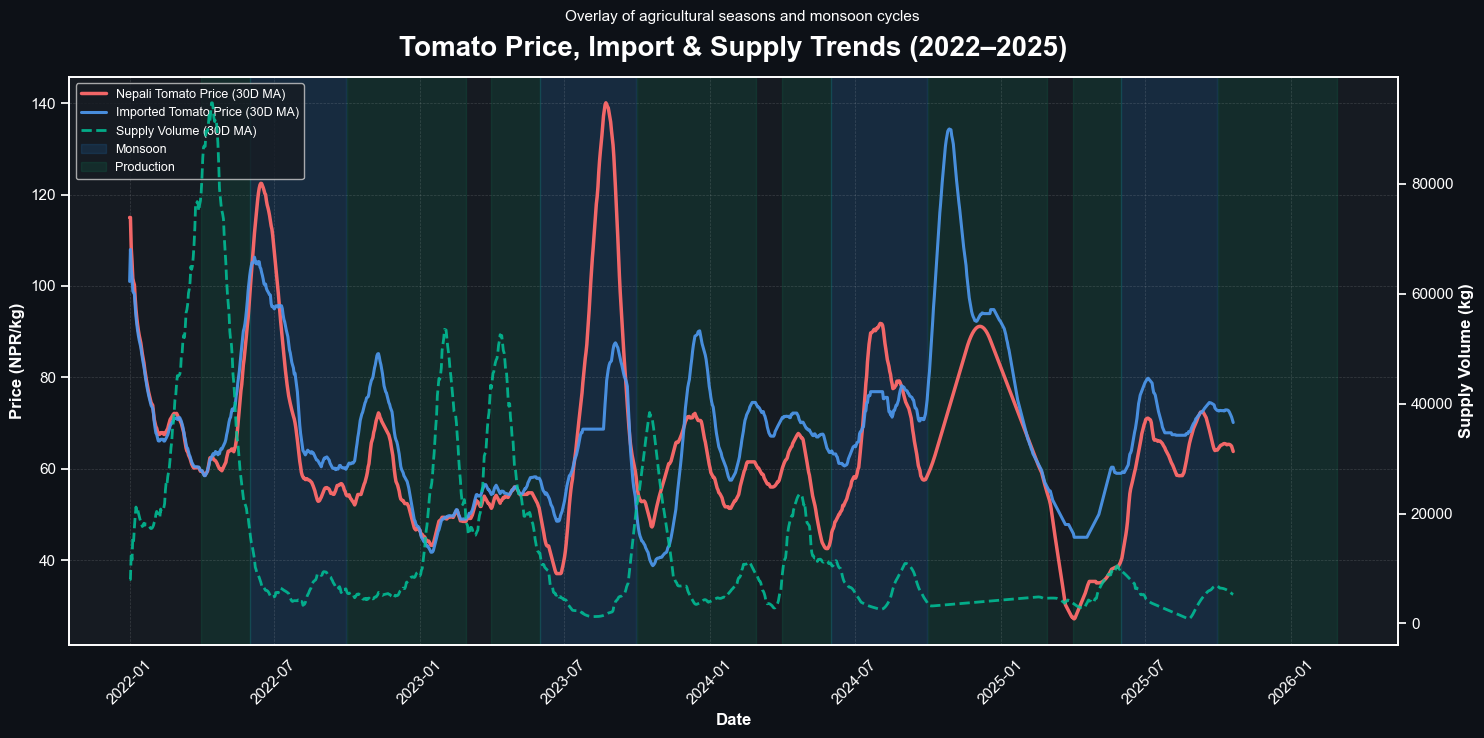

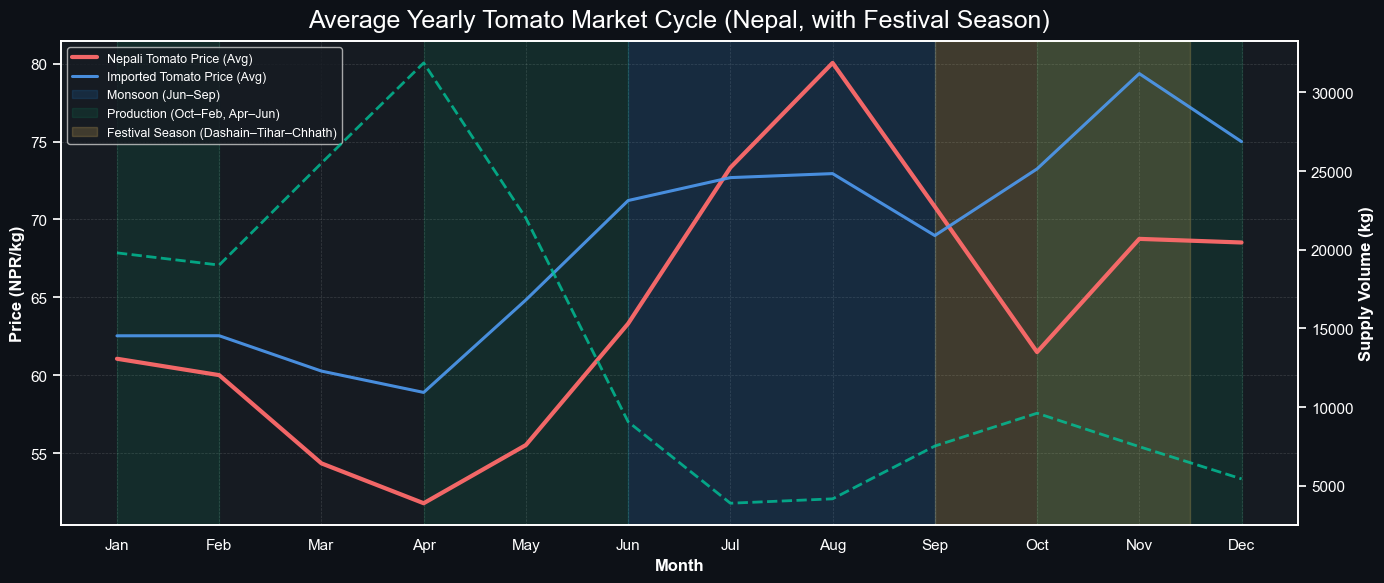

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1️⃣ Create visualization copy ---
df_viz = df.copy()

if not isinstance(df_viz.index, pd.DatetimeIndex):
    df_viz['Date'] = pd.to_datetime(df_viz['Date'])
    df_viz = df_viz.sort_values('Date')
    df_viz.set_index('Date', inplace=True)

# --- 2️⃣ Rolling averages ---
df_viz['Nepali_Rolling'] = df_viz['Average_Price'].rolling(window=30, min_periods=1).mean()
df_viz['Imported_Rolling'] = df_viz['imported_tomato_price'].rolling(window=30, min_periods=1).mean()
df_viz['Supply_Rolling'] = df_viz['Supply_Volume'].rolling(window=30, min_periods=1).mean()

# ======================================================
# FIGURE 1 — Multi-Year Rolling Trend (NO FESTIVALS)
# ======================================================

fig, ax1 = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('#0D1117')
ax1.set_facecolor('#161B22')

# --- Plot price lines ---
ax1.plot(df_viz.index, df_viz['Nepali_Rolling'],
         color='#FF6B6B', linewidth=2.5, label='Nepali Tomato Price (30D MA)', alpha=0.95)
ax1.plot(df_viz.index, df_viz['Imported_Rolling'],
         color='#4E9AF1', linewidth=2.2, label='Imported Tomato Price (30D MA)', alpha=0.9)

# --- Supply on secondary axis ---
ax2 = ax1.twinx()
ax2.plot(df_viz.index, df_viz['Supply_Rolling'],
         color='#00C49A', linewidth=2, linestyle='--', label='Supply Volume (30D MA)', alpha=0.85)

# --- Seasonal and climate shading ---
for year in df_viz.index.year.unique():
    # Monsoon
    ax1.axvspan(pd.Timestamp(f'{year}-06-01'), pd.Timestamp(f'{year}-09-30'),
                color='#1E88E5', alpha=0.15, zorder=0)
    # Tomato production windows
    ax1.axvspan(pd.Timestamp(f'{year}-10-01'), pd.Timestamp(f'{year+1}-02-28'),
                color='#00FF99', alpha=0.08, zorder=0)
    ax1.axvspan(pd.Timestamp(f'{year}-04-01'), pd.Timestamp(f'{year}-06-01'),
                color='#00FF99', alpha=0.08, zorder=0)

# --- Labels and legend (text in white) ---
ax1.set_title("Tomato Price, Import & Supply Trends (2022–2025)",
              fontsize=20, fontweight='bold', color='white', pad=15)
plt.suptitle("Overlay of agricultural seasons and monsoon cycles",
             fontsize=11, color='white', y=0.92)

ax1.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.15)  # subtle grid
ax2.grid(False)  # optional: don't grid secondary axis, or match alpha=0.15 if you like

ax1.set_xlabel("Date", fontsize=12, color='white', fontweight='bold')
ax1.set_ylabel("Price (NPR/kg)", fontsize=12, color='white', fontweight='bold')
ax2.set_ylabel("Supply Volume (kg)", fontsize=12, color='white', fontweight='bold')

ax1.tick_params(axis='x', colors='white', rotation=45)
ax1.tick_params(axis='y', colors='white')
ax2.tick_params(axis='y', colors='white')

# --- Legend patches ---
monsoon_patch = mpatches.Patch(color='#1E88E5', alpha=0.15, label='Monsoon (Jun–Sep)')
prod_patch = mpatches.Patch(color='#00FF99', alpha=0.08, label='Production Season')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

leg = ax1.legend(lines1 + lines2 + [monsoon_patch, prod_patch],
                 labels1 + labels2 + ['Monsoon', 'Production'],
                 loc='upper left', fontsize=9, frameon=True)
leg.get_frame().set_facecolor('#161B22')
for text in leg.get_texts():
    text.set_color('white')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ======================================================
# FIGURE 2 — Average Yearly Cycle (WITH FESTIVAL SEASON)
# ======================================================

df_viz['Month'] = df_viz.index.month
yearly_avg = df_viz.groupby('Month')[['Average_Price', 'imported_tomato_price', 'Supply_Volume']].mean()
yearly_avg = yearly_avg.rolling(window=2, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')
ax1.set_facecolor('#161B22')

# Plot
ax1.plot(yearly_avg.index, yearly_avg['Average_Price'],
         color='#FF6B6B', linewidth=3, label='Nepali Tomato Price (Avg)', alpha=0.95)
ax1.plot(yearly_avg.index, yearly_avg['imported_tomato_price'],
         color='#4E9AF1', linewidth=2.2, label='Imported Tomato Price (Avg)', alpha=0.9)

ax2 = ax1.twinx()
ax2.plot(yearly_avg.index, yearly_avg['Supply_Volume'],
         color='#00C49A', linewidth=2, linestyle='--', label='Supply Volume (Avg)', alpha=0.8)

# --- Shading: monsoon, production, and unified festival period ---
ax1.axvspan(6, 9, color='#1E88E5', alpha=0.15, label='Monsoon (Jun–Sep)')
ax1.axvspan(10, 12, color='#00FF99', alpha=0.08)
ax1.axvspan(1, 2, color='#00FF99', alpha=0.08)
ax1.axvspan(4, 6, color='#00FF99', alpha=0.08, label='Production (Oct–Feb, Apr–Jun)')

ax1.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.15)  # subtle grid
ax2.grid(False)  # optional: don't grid secondary axis, or match alpha=0.15 if you like

# FIGURE 2 — Average Yearly Cycle
ax1.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.15)  # subtle grid
ax2.grid(False)

# Unified Festival Season (Sept–Nov)
ax1.axvspan(9, 11.5, color='#FFD166', alpha=0.18, label='Festival Season (Dashain–Tihar–Chhath)')

# --- Labels (text in white) ---
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], color='white')

ax1.set_title("Average Yearly Tomato Market Cycle (Nepal, with Festival Season)",
              fontsize=18, color='white', pad=10)
ax1.set_xlabel("Month", fontsize=12, color='white', fontweight='bold')
ax1.set_ylabel("Price (NPR/kg)", fontsize=12, color='white', fontweight='bold')
ax2.set_ylabel("Supply Volume (kg)", fontsize=12, color='white', fontweight='bold')

leg = ax1.legend(loc='upper left', fontsize=9, frameon=True)
leg.get_frame().set_facecolor('#161B22')
for text in leg.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()


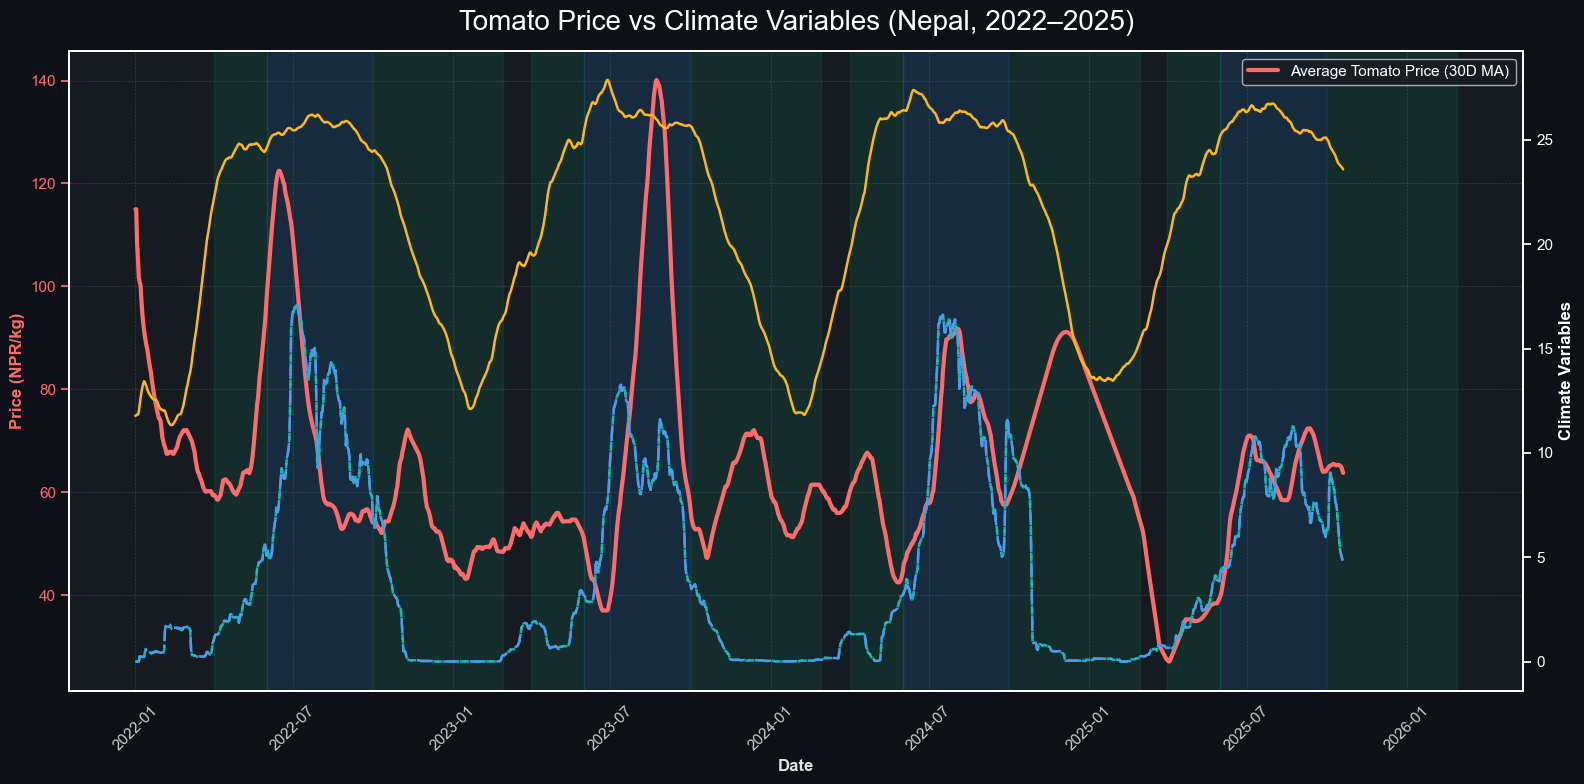

In [32]:
# --- Copy dataframe for visualization ---
df_viz = df.copy()

# Ensure datetime index
if not isinstance(df_viz.index, pd.DatetimeIndex):
    df_viz['Date'] = pd.to_datetime(df_viz['Date'])
    df_viz = df_viz.sort_values('Date')
    df_viz.set_index('Date', inplace=True)

# --- Rolling Averages for smoother trends ---
df_viz['AvgPrice_Roll'] = df_viz['Average_Price'].rolling(window=30, min_periods=1).mean()
df_viz['Avg_Temp'] = df_viz[['Hilly_Temperature','Sarlahi_Temperature']].mean(axis=1).rolling(30, min_periods=1).mean()
df_viz['Avg_Rainfall'] = df_viz[['Hilly_Rainfall_MM','Sarlahi_Rainfall_MM']].mean(axis=1).rolling(30, min_periods=1).mean()
df_viz['Avg_Precip'] = df_viz[['Hilly_Precipitation','Sarlahi_Precipitation']].mean(axis=1).rolling(30, min_periods=1).mean()

# --- Dark theme ---
sns.set_theme(style="darkgrid")
plt.style.use("dark_background")

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(16, 8))
fig.patch.set_facecolor('#0D1117')
ax1.set_facecolor('#161B22')

# Tomato price (thicker)
ax1.plot(df_viz.index, df_viz['AvgPrice_Roll'], color='#FF6B6B', linewidth=3, label='Average Tomato Price (30D MA)')

# Secondary axis for climate
ax2 = ax1.twinx()
ax2.plot(df_viz.index, df_viz['Avg_Temp'], color='#FDB813', linewidth=1.8, linestyle='-', label='Avg Temperature')
ax2.plot(df_viz.index, df_viz['Avg_Rainfall'], color='#00C49A', linewidth=1.8, linestyle='--', label='Avg Rainfall')
ax2.plot(df_viz.index, df_viz['Avg_Precip'], color='#4E9AF1', linewidth=1.8, linestyle='-.', label='Avg Precipitation')

# --- Titles & labels ---
ax1.set_title("Tomato Price vs Climate Variables (Nepal, 2022–2025)", fontsize=20, color='white', pad=15)
ax1.set_xlabel("Date", fontsize=12, color='#E5E5E5', fontweight='bold')
ax1.set_ylabel("Price (NPR/kg)", fontsize=12, color='#FF6B6B', fontweight='bold')
ax2.set_ylabel("Climate Variables", fontsize=12, color='white', fontweight='bold')

# Grid & ticks
ax1.tick_params(axis='x', colors='#CCCCCC', rotation=45)
ax1.tick_params(axis='y', colors='#FF6B6B')
ax2.tick_params(axis='y', colors='white')
ax1.grid(True, linestyle='--', alpha=0.3)

ax1.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.15)  # subtle grid
ax2.grid(False)  # optional: don't grid secondary axis, or match alpha=0.15 if you like

# --- Optional patches for seasons ---
for year in df_viz.index.year.unique():
    # Monsoon June–Sept
    ax1.axvspan(pd.Timestamp(f'{year}-06-01'), pd.Timestamp(f'{year}-09-30'), color='#1E88E5', alpha=0.15)
    # Production Oct–Feb & Apr–Jun
    ax1.axvspan(pd.Timestamp(f'{year}-10-01'), pd.Timestamp(f'{year+1}-02-28'), color='#00FF99', alpha=0.08)
    ax1.axvspan(pd.Timestamp(f'{year}-04-01'), pd.Timestamp(f'{year}-06-01'), color='#00FF99', alpha=0.08)

# --- Legends ---
monsoon_patch = plt.Line2D([0], [0], color='#1E88E5', alpha=0.15, linewidth=10, label='Monsoon Season')
prod_patch = plt.Line2D([0], [0], color='#00FF99', alpha=0.08, linewidth=10, label='Production Season')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + [monsoon_patch, prod_patch],
           labels1 + labels2 + ['Monsoon Season', 'Production Season'],
           loc='upper left', fontsize=10, frameon=True)
ax1.legend(frameon=True, facecolor='#161B22')

plt.tight_layout()
plt.show()

In [23]:
df.columns

Index(['Average_Price', 'Supply_Volume', 'USD_TO_NPR', 'Diesel', 'is_festival',
       'imported_tomato_price', 'Season_Autumn', 'Season_Monsoon',
       'Season_Spring', 'Season_Winter', 'Inflation', 'Dhading_Wind_Speed',
       'Dhading_Temperature', 'Dhading_Precipitation', 'Dhading_Rainfall_MM',
       'Dhading_Air_Pressure', 'Kathmandu_Wind_Speed', 'Kathmandu_Temperature',
       'Kathmandu_Precipitation', 'Kathmandu_Rainfall_MM',
       'Kathmandu_Air_Pressure', 'Kavre_Wind_Speed', 'Kavre_Temperature',
       'Kavre_Precipitation', 'Kavre_Rainfall_MM', 'Kavre_Air_Pressure',
       'Sarlahi_Wind_Speed', 'Sarlahi_Temperature', 'Sarlahi_Precipitation',
       'Sarlahi_Rainfall_MM', 'Sarlahi_Air_Pressure', 'Hilly_Temperature',
       'Hilly_Precipitation', 'Hilly_Air_Pressure', 'Hilly_Rainfall_MM'],
      dtype='object')

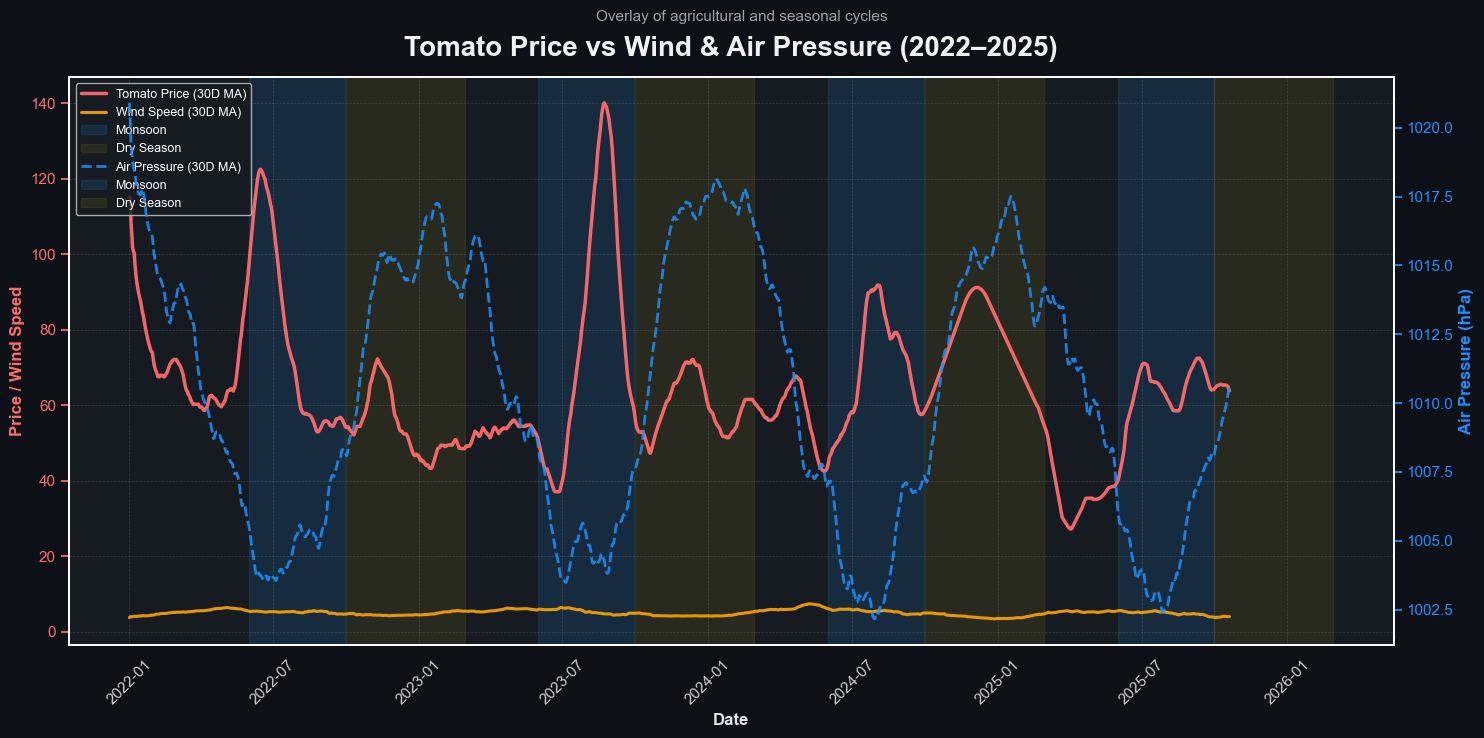

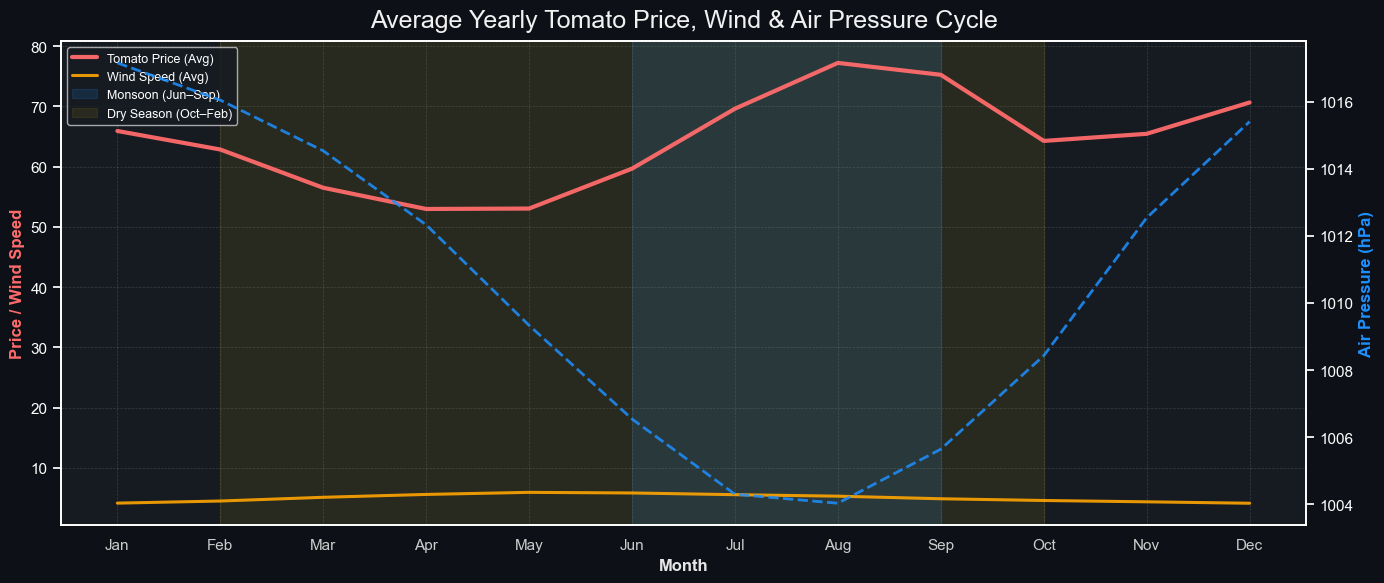

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- 1️⃣ Prepare visualization copy ---
df_weather = df.copy()

if not isinstance(df_weather.index, pd.DatetimeIndex):
    df_weather['Date'] = pd.to_datetime(df_weather['Date'])
    df_weather = df_weather.sort_values('Date')
    df_weather.set_index('Date', inplace=True)

# --- 2️⃣ Rolling averages ---
# Price
df_weather['Price_Rolling'] = df_weather['Average_Price'].rolling(window=30, min_periods=1).mean()
# Wind & Pressure: Sarlahi + Hilly proxies (Dhading, Kathmandu, Kavre)
df_weather['Wind_Avg'] = df_weather[['Sarlahi_Wind_Speed','Dhading_Wind_Speed','Kathmandu_Wind_Speed','Kavre_Wind_Speed']].mean(axis=1)
df_weather['Wind_Rolling'] = df_weather['Wind_Avg'].rolling(window=30, min_periods=1).mean()

df_weather['Pressure_Avg'] = df_weather[['Sarlahi_Air_Pressure','Dhading_Air_Pressure','Kathmandu_Air_Pressure','Kavre_Air_Pressure']].mean(axis=1)
df_weather['Pressure_Rolling'] = df_weather['Pressure_Avg'].rolling(window=30, min_periods=1).mean()

# ======================================================
# FIGURE 1 — Multi-Year Rolling Trend
# ======================================================

fig, ax1 = plt.subplots(figsize=(15, 8))
fig.patch.set_facecolor('#0D1117')
ax1.set_facecolor('#161B22')

# --- Plot average price ---
ax1.plot(df_weather.index, df_weather['Price_Rolling'],
         color='#FF6B6B', linewidth=2.5, label='Tomato Price (30D MA)', alpha=0.95)
# --- Wind on same axis (optional) ---
ax1.plot(df_weather.index, df_weather['Wind_Rolling'],
         color='#FFA500', linewidth=2.2, label='Wind Speed (30D MA)', alpha=0.9)

# --- Pressure on secondary axis ---
ax2 = ax1.twinx()
ax2.plot(df_weather.index, df_weather['Pressure_Rolling'],
         color='#1E90FF', linewidth=2, linestyle='--', label='Air Pressure (30D MA)', alpha=0.85)

# --- Seasonal shading ---
for year in df_weather.index.year.unique():
    ax1.axvspan(pd.Timestamp(f'{year}-06-01'), pd.Timestamp(f'{year}-09-30'),
                color='#1E88E5', alpha=0.15, zorder=0, label='Monsoon' if year==df_weather.index.year.min() else "")
    ax1.axvspan(pd.Timestamp(f'{year}-10-01'), pd.Timestamp(f'{year+1}-02-28'),
                color='#FFD700', alpha=0.08, zorder=0, label='Dry Season' if year==df_weather.index.year.min() else "")

ax1.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.15)  # subtle grid
ax2.grid(False)  # optional: don't grid secondary axis, or match alpha=0.15 if you like

# --- Labels ---
ax1.set_title("Tomato Price vs Wind & Air Pressure (2022–2025)", fontsize=20, fontweight='bold', color='#F1F1F1', pad=15)
plt.suptitle("Overlay of agricultural and seasonal cycles", fontsize=11, color='#A0A0A0', y=0.92)

ax1.set_xlabel("Date", fontsize=12, color='#E5E5E5', fontweight='bold')
ax1.set_ylabel("Price / Wind Speed", fontsize=12, color='#FF6B6B', fontweight='bold')
ax2.set_ylabel("Air Pressure (hPa)", fontsize=12, color='#1E90FF', fontweight='bold')

ax1.tick_params(axis='x', colors='#CCCCCC', rotation=45)
ax1.tick_params(axis='y', colors='#FF6B6B')
ax2.tick_params(axis='y', colors='#1E90FF')

# --- Legend ---
monsoon_patch = mpatches.Patch(color='#1E88E5', alpha=0.15, label='Monsoon (Jun–Sep)')
dry_patch = mpatches.Patch(color='#FFD700', alpha=0.08, label='Dry Season (Oct–Feb)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
leg = ax1.legend(lines1 + lines2 + [monsoon_patch, dry_patch],
                 labels1 + labels2 + ['Monsoon', 'Dry Season'],
                 loc='upper left', fontsize=9, frameon=True)
leg.get_frame().set_facecolor('#161B22')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# ======================================================
# FIGURE 2 — Average Yearly Cycle
# ======================================================

df_weather['Month'] = df_weather.index.month
yearly_avg = df_weather.groupby('Month')[['Price_Rolling','Wind_Rolling','Pressure_Rolling']].mean()
yearly_avg = yearly_avg.rolling(window=2, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#0D1117')
ax1.set_facecolor('#161B22')

ax1.plot(yearly_avg.index, yearly_avg['Price_Rolling'],
         color='#FF6B6B', linewidth=3, label='Tomato Price (Avg)', alpha=0.95)
ax1.plot(yearly_avg.index, yearly_avg['Wind_Rolling'],
         color='#FFA500', linewidth=2.2, label='Wind Speed (Avg)', alpha=0.9)

ax2 = ax1.twinx()
ax2.plot(yearly_avg.index, yearly_avg['Pressure_Rolling'],
         color='#1E90FF', linewidth=2, linestyle='--', label='Air Pressure (Avg)', alpha=0.85)

ax1.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.15)  # subtle grid
ax2.grid(False)  # optional: don't grid secondary axis, or match alpha=0.15 if you like

# Seasonal shading
ax1.axvspan(6, 9, color='#1E88E5', alpha=0.15, label='Monsoon (Jun–Sep)')
ax1.axvspan(10, 2, color='#FFD700', alpha=0.08, label='Dry Season (Oct–Feb)')  # wraps around year

# Labels
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], color='#CCCCCC')

ax1.set_title("Average Yearly Tomato Price, Wind & Air Pressure Cycle", fontsize=18, color='#F1F1F1', pad=10)
ax1.set_xlabel("Month", fontsize=12, color='#E5E5E5', fontweight='bold')
ax1.set_ylabel("Price / Wind Speed", fontsize=12, color='#FF6B6B', fontweight='bold')
ax2.set_ylabel("Air Pressure (hPa)", fontsize=12, color='#1E90FF', fontweight='bold')

leg = ax1.legend(loc='upper left', fontsize=9, frameon=True)
leg.get_frame().set_facecolor('#161B22')

plt.tight_layout()
plt.show()


In [ ]:
df=df.drop(columns=remove_cols)

NameError: name 'remove_columns' is not defined

In [ ]:
df.columns

Index(['Average_Price', 'Supply_Volume', 'USD_TO_NPR', 'Diesel', 'is_festival',
       'Season_Autumn', 'Season_Monsoon', 'Season_Spring', 'Season_Winter',
       'Inflation', 'Kathmandu_Rainfall_MM', 'Sarlahi_Temperature',
       'Sarlahi_Precipitation', 'Sarlahi_Rainfall_MM', 'Hilly_Temperature',
       'Hilly_Precipitation', 'Hilly_Rainfall_MM'],
      dtype='object')

In [ ]:
print("Shape:", df.shape)
print("\nSample:")
display(df.head())

Shape: (1389, 17)

Sample:


,Average_Price,Supply_Volume,USD_TO_NPR,Diesel,is_festival,Season_Autumn,Season_Monsoon,Season_Spring,Season_Winter,Inflation,Kathmandu_Rainfall_MM,Sarlahi_Temperature,Sarlahi_Precipitation,Sarlahi_Rainfall_MM,Hilly_Temperature,Hilly_Precipitation,Hilly_Rainfall_MM
Date,,,,,,,,,,,,,,,,,
2022-01-01,115.00,8000.0,119.24,119.0,0,False,False,False,True,6.03,0.0,13.361168,0.0,0.0,10.193583,0.0,0.0
2022-01-02,115.00,8000.0,119.24,119.0,0,False,False,False,True,6.03,0.0,12.967416,0.0,0.0,10.681083,0.0,0.0
2022-01-03,95.00,22375.0,119.24,119.0,0,False,False,False,True,6.03,0.0,12.807000,0.0,0.0,11.019625,0.0,0.0
2022-01-04,96.67,8000.0,119.12,119.0,0,False,False,False,True,6.03,0.0,12.761169,0.0,0.0,10.984209,0.0,0.0
2022-01-05,86.67,32500.0,119.59,119.0,0,False,False,False,True,6.03,0.0,13.677834,0.0,0.0,11.434209,0.0,0.0


In [ ]:
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1389 entries, 2022-01-01 to 2025-10-20
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Average_Price          1389 non-null   float64
 1   Supply_Volume          1389 non-null   float64
 2   USD_TO_NPR             1389 non-null   float64
 3   Diesel                 1389 non-null   float64
 4   is_festival            1389 non-null   int64  
 5   Season_Autumn          1389 non-null   bool   
 6   Season_Monsoon         1389 non-null   bool   
 7   Season_Spring          1389 non-null   bool   
 8   Season_Winter          1389 non-null   bool   
 9   Inflation              1389 non-null   float64
 10  Kathmandu_Rainfall_MM  1389 non-null   float64
 11  Sarlahi_Temperature    1389 non-null   float64
 12  Sarlahi_Precipitation  1389 non-null   float64
 13  Sarlahi_Rainfall_MM    1389 non-null   float64
 14  Hilly_Temperatur

In [ ]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Average_Price            0
Supply_Volume            0
USD_TO_NPR               0
Diesel                   0
is_festival              0
Season_Autumn            0
Season_Monsoon           0
Season_Spring            0
Season_Winter            0
Inflation                0
Kathmandu_Rainfall_MM    0
Sarlahi_Temperature      0
Sarlahi_Precipitation    0
Sarlahi_Rainfall_MM      0
Hilly_Temperature        0
Hilly_Precipitation      0
Hilly_Rainfall_MM        0
dtype: int64


In [ ]:
# Handle missing values (simple strategy)
# df = df.fillna(method="ffill").fillna(method="bfill")
df['Supply_Volume'] = df['Supply_Volume'].interpolate(method='linear')
df['Supply_Volume'] = df['Supply_Volume'].ffill().bfill()

# Remove duplicates if any
df = df.drop_duplicates()


In [ ]:
df['Supply_Volume'] = df['Supply_Volume'].replace(0, np.nan)
df['Supply_Volume'] = df['Supply_Volume'].ffill().bfill()

In [ ]:

print("\n After cleaning:")
print(df.shape)


 After cleaning:
(1389, 17)


In [ ]:
print("\n--- Descriptive Statistics ---")
display(df.describe().T)


--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
Average_Price,1389.0,64.058099,22.037352,17.670000,53.330000,60.290000,74.090000,170.000000
Supply_Volume,1389.0,13530.340475,20907.117991,10.000000,3099.378882,5000.000000,12000.000000,185920.000000
USD_TO_NPR,1389.0,132.577279,5.150641,118.520000,131.320000,133.270000,135.110000,142.380000
Diesel,1389.0,157.093952,13.093304,119.000000,150.000000,155.000000,166.250000,178.000000
is_festival,1389.0,0.197264,0.398077,0.000000,0.000000,0.000000,0.000000,1.000000
Inflation,1389.0,5.679086,1.967629,1.680000,4.160000,6.030000,7.440000,8.640000
Kathmandu_Rainfall_MM,1389.0,6.198848,12.676388,0.000000,0.000000,1.200000,6.900000,181.700000
Sarlahi_Temperature,1389.0,24.140016,5.677685,10.300751,19.494501,26.388250,28.752836,34.727833
Sarlahi_Precipitation,1389.0,3.689705,8.905114,0.000000,0.000000,0.000000,2.700000,123.400010
Sarlahi_Rainfall_MM,1389.0,3.689705,8.905114,0.000000,0.000000,0.000000,2.700000,123.400010


In [ ]:
df.describe().to_csv("artifacts/data/summary_stats.csv")


In [ ]:
# Helper function to save figures automatically
def save_fig(fig, name):
    fig_path = f"artifacts/eda_images/{name}.png"
    fig.savefig(fig_path, bbox_inches='tight', dpi=200)
    plt.close(fig)
    print(f" Saved: {fig_path}")


In [ ]:
drop_cols = [
    # Non-relevant or redundant
    'imported_tomato_price',

    # Drop all precipitation & air pressure (noisy / redundant)
    'Dhading_Precipitation', 'Kathmandu_Precipitation', 'Kavre_Precipitation', 'Sarlahi_Precipitation', 'Hilly_Precipitation',
    'Dhading_Air_Pressure', 'Kathmandu_Air_Pressure', 'Kavre_Air_Pressure', 'Sarlahi_Air_Pressure',

    # Drop Kavre & Dhading entire region set (redundant)
    'Dhading_Wind_Speed', 'Dhading_Temperature', 'Dhading_Rainfall_MM',
    'Kavre_Wind_Speed', 'Kavre_Temperature', 'Kavre_Rainfall_MM'
]

# --- 2️⃣ Create final feature list ---
remaining_features = [c for c in df.columns if c not in drop_cols]

print("✅ Columns kept:", remaining_features)
print("\n❌ Columns dropped:", drop_cols)

# --- 3️⃣ Drop from DataFrame ---
df = df[remaining_features].copy()

✅ Columns kept: ['Average_Price', 'Supply_Volume', 'USD_TO_NPR', 'Diesel', 'is_festival', 'Season_Autumn', 'Season_Monsoon', 'Season_Spring', 'Season_Winter', 'Inflation', 'Kathmandu_Rainfall_MM', 'Sarlahi_Temperature', 'Sarlahi_Rainfall_MM', 'Hilly_Temperature', 'Hilly_Rainfall_MM']

❌ Columns dropped: ['imported_tomato_price', 'Dhading_Precipitation', 'Kathmandu_Precipitation', 'Kavre_Precipitation', 'Sarlahi_Precipitation', 'Hilly_Precipitation', 'Dhading_Air_Pressure', 'Kathmandu_Air_Pressure', 'Kavre_Air_Pressure', 'Sarlahi_Air_Pressure', 'Dhading_Wind_Speed', 'Dhading_Temperature', 'Dhading_Rainfall_MM', 'Kavre_Wind_Speed', 'Kavre_Temperature', 'Kavre_Rainfall_MM']


In [ ]:
num_cols = df.select_dtypes(include=['number','bool']).columns


In [ ]:
for col in num_cols:
    fig, ax = plt.subplots(figsize=(6,4))
    sns.histplot(df[col], kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribution of {col}")
    save_fig(fig, f"dist_{col}")


 Saved: artifacts/eda_images/dist_Average_Price.png
 Saved: artifacts/eda_images/dist_Supply_Volume.png
 Saved: artifacts/eda_images/dist_USD_TO_NPR.png
 Saved: artifacts/eda_images/dist_Diesel.png
 Saved: artifacts/eda_images/dist_is_festival.png
 Saved: artifacts/eda_images/dist_Season_Autumn.png
 Saved: artifacts/eda_images/dist_Season_Monsoon.png
 Saved: artifacts/eda_images/dist_Season_Spring.png
 Saved: artifacts/eda_images/dist_Season_Winter.png
 Saved: artifacts/eda_images/dist_Inflation.png
 Saved: artifacts/eda_images/dist_Kathmandu_Rainfall_MM.png
 Saved: artifacts/eda_images/dist_Sarlahi_Temperature.png
 Saved: artifacts/eda_images/dist_Sarlahi_Rainfall_MM.png
 Saved: artifacts/eda_images/dist_Hilly_Temperature.png
 Saved: artifacts/eda_images/dist_Hilly_Rainfall_MM.png


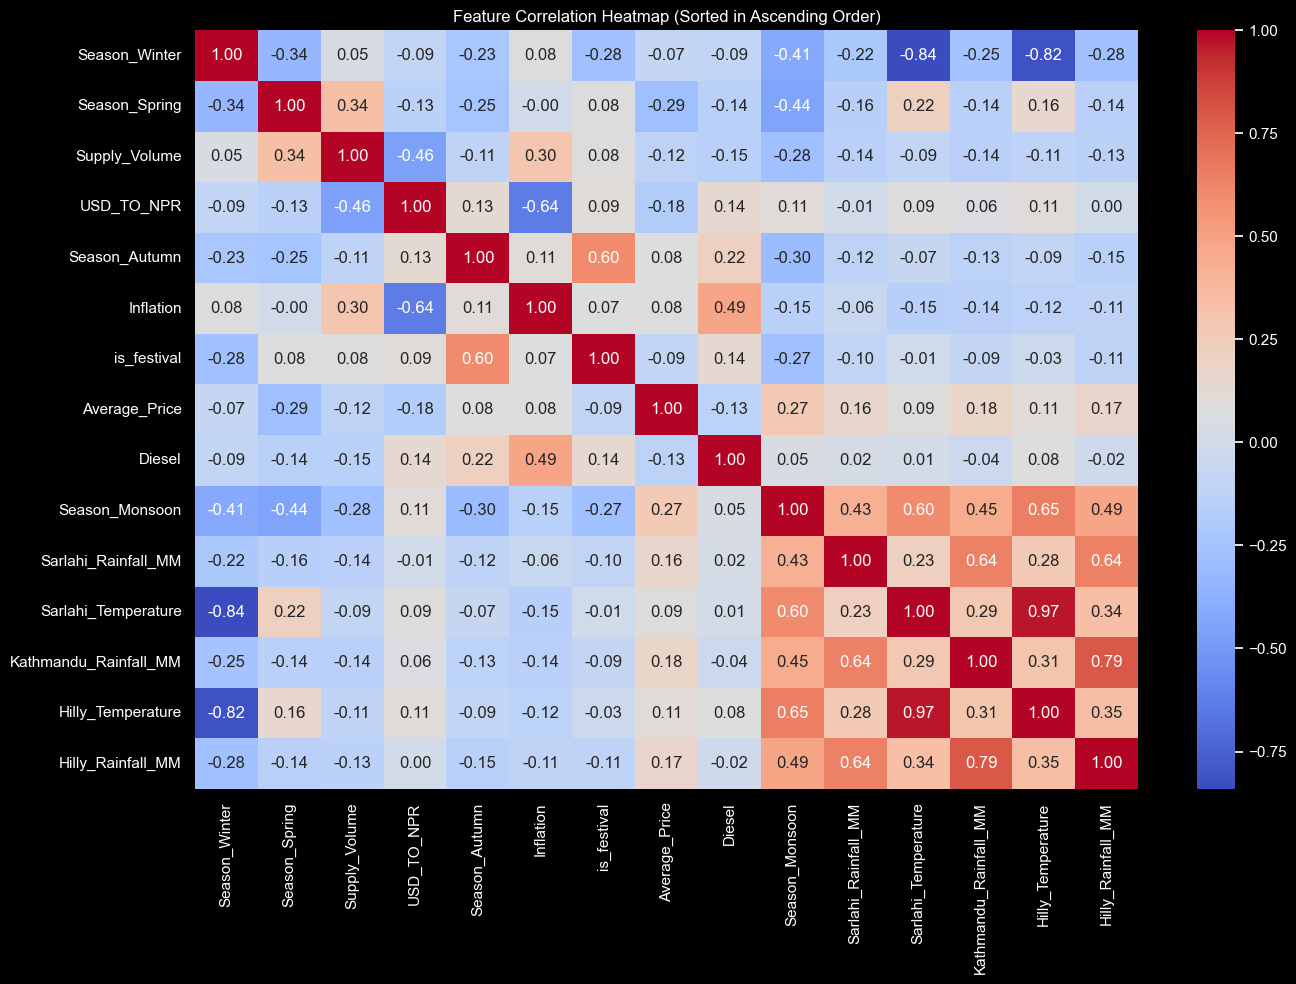

 Saved: artifacts/eda_images/correlation_heatmap_default.png


In [ ]:
# Compute correlation matrix
corr = df[num_cols].corr()

# Sort features by mean correlation value (ascending order)
sorted_cols = corr.mean().sort_values(ascending=True).index
corr_sorted = corr.loc[sorted_cols, sorted_cols]

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_sorted, annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
ax.set_title("Feature Correlation Heatmap (Sorted in Ascending Order)")
plt.tight_layout()
plt.show()

# Save figure
save_fig(fig, "correlation_heatmap_default")

In [ ]:
# --- Pairplot (relationships) ---
# fig = sns.pairplot(df[num_cols], diag_kind="kde")
# fig.fig.suptitle("Pairwise Relationships", y=1.02)
# fig.savefig("artifacts/eda_images/pairplot.png", dpi=150)
# plt.show()
# plt.close()
# print("📸 Saved: artifacts/eda_images/pairplot.png")

<Axes: >

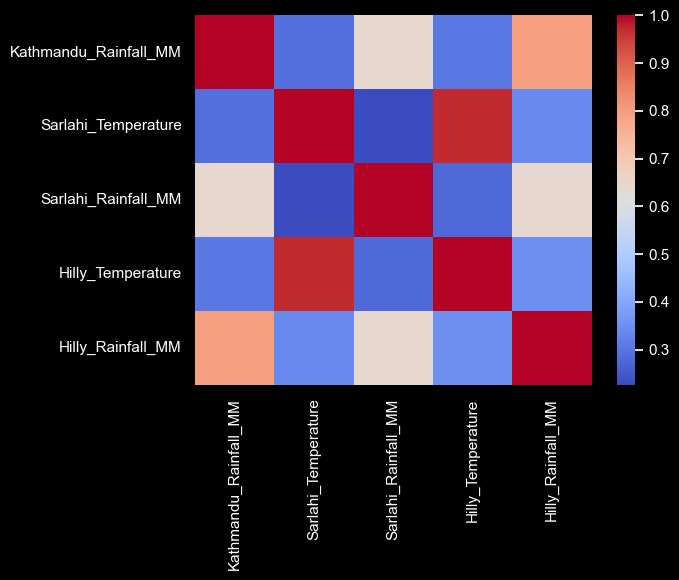

In [ ]:
climate_df = df[[c for c in df.columns if 'Hilly' in c or 'Kathmandu' in c or 'Sarlahi' in c]]
climate_corr = climate_df.corr().abs()
sns.heatmap(climate_corr,cmap='coolwarm',)


In [ ]:
# --- Violinplots to visualize distributions + outliers ---
for col in num_cols:
    fig, ax = plt.subplots(figsize=(5,4))
    sns.violinplot(x=df[col], inner="quartile", color='lightblue', ax=ax)
    ax.set_title(f"Violin Plot of {col}")
    # plt.show()
    save_fig(fig, f"violin_{col}")


 Saved: artifacts/eda_images/violin_Average_Price.png
 Saved: artifacts/eda_images/violin_Supply_Volume.png
 Saved: artifacts/eda_images/violin_USD_TO_NPR.png
 Saved: artifacts/eda_images/violin_Diesel.png
 Saved: artifacts/eda_images/violin_is_festival.png
 Saved: artifacts/eda_images/violin_Season_Autumn.png
 Saved: artifacts/eda_images/violin_Season_Monsoon.png
 Saved: artifacts/eda_images/violin_Season_Spring.png
 Saved: artifacts/eda_images/violin_Season_Winter.png
 Saved: artifacts/eda_images/violin_Inflation.png
 Saved: artifacts/eda_images/violin_Kathmandu_Rainfall_MM.png
 Saved: artifacts/eda_images/violin_Sarlahi_Temperature.png
 Saved: artifacts/eda_images/violin_Sarlahi_Rainfall_MM.png
 Saved: artifacts/eda_images/violin_Hilly_Temperature.png
 Saved: artifacts/eda_images/violin_Hilly_Rainfall_MM.png


In [ ]:
if "imported_tomato_price" in df.columns:
    season_cols = [c for c in df.columns if c.startswith("Season_")]
    for season in season_cols:
        fig, ax = plt.subplots(figsize=(5,4))
        sns.boxplot(x=df[season], y=df["imported_tomato_price"], ax=ax)
        ax.set_title(f"Tomato Price vs {season}")
        plt.show()
        save_fig(fig, f"price_vs_{season}")

In [ ]:
# if not np.issubdtype(df['Date'].dtype, np.datetime64):
#     df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# # --- Temporal Decomposition ---
df['day'] = df.index.day
df['month'] = df.index.month
df['day_of_week'] = df.index.dayofweek  # Monday=0, Sunday=6
df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)

# Cyclical (sin/cos) features
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df.index.name='Date'
df.reset_index(inplace=True)

col_categories["temporal_cols"].extend(['Date','day', 'month', 'day_of_week', 'is_weekend', 'month_sin', 'month_cos'])

print("\n Temporal & Cyclical features extracted:")
print(df[['Date','day', 'month', 'day_of_week', 'is_weekend', 'month_sin', 'month_cos']].head())



 Temporal & Cyclical features extracted:
        Date  day  month  day_of_week  is_weekend  month_sin  month_cos
0 2022-01-01    1      1            5           1        0.5   0.866025
1 2022-01-02    2      1            6           1        0.5   0.866025
2 2022-01-03    3      1            0           0        0.5   0.866025
3 2022-01-04    4      1            1           0        0.5   0.866025
4 2022-01-05    5      1            2           0        0.5   0.866025


In [ ]:
# def create_lag_features(df, lag_config):
#     """
#     Create lag features for multiple columns, each with custom lag ranges.
    
#     Parameters:
#         df (pd.DataFrame): The input dataframe.
#         lag_config (dict): Dictionary like {'col_name': [1, 3, 7], ...}
#     """
#     df_lagged = df.copy()
#     for col, lags in lag_config.items():
#         for lag in lags:
#             col_name = f"{col}_lag{lag}"
#             df_lagged[col_name] = df_lagged[col].shift(lag)
            
#             # Add to respective category
#             for col_category in col_categories.keys():
#                 if col in col_categories[col_category]:
#                     col_categories[col_category].append(col_name)
#     return df_lagged


# def create_rolling_features(df, roll_config, use_std=False):
#     """
#     Create rolling mean and (optionally) std features with custom windows per column.
    
#     Parameters:
#         df (pd.DataFrame): The input dataframe.
#         roll_config (dict): Dictionary like {'col_name': [7, 30], ...}
#         use_std (bool): Whether to include rolling std features.
#     """
#     df_roll = df.copy()
#     for col, windows in roll_config.items():
#         for w in windows:
#             mean_col = f"{col}_rollmean_{w}"
#             df_roll[mean_col] = df_roll[col].rolling(window=w).mean()
            
#             # Add to respective category
#             for col_category in col_categories.keys():
#                 if col in col_categories[col_category]:
#                     col_categories[col_category].append(mean_col)
            
#             if use_std:
#                 std_col = f"{col}_rollstd_{w}"
#                 df_roll[std_col] = df_roll[col].rolling(window=w).std()
                
#                 for col_category in col_categories.keys():
#                     if col in col_categories[col_category]:
#                         col_categories[col_category].append(std_col)
#     return df_roll


# def combine_lag_and_roll(df, lag_config, roll_config, use_std=False):
#     """
#     Combine lag and rolling features per-column with custom configurations.
#     """
#     df_combo = create_lag_features(df, lag_config)
#     df_combo = create_rolling_features(df_combo, roll_config, use_std=use_std)
#     df_combo = df_combo.dropna().reset_index(drop=True)
#     return df_combo


In [ ]:
# # Create lagged features using per-column lag configuration
# df_with_lags = create_lag_features(df, lag_config=custom_lag_config)

# # Create rolling features using per-column rolling configuration
# df_with_rolls = create_rolling_features(df, roll_config=custom_roll_config, use_std=standard_deviation_lag)

# # Combine both lag and rolling features
# df_with_lag_roll = combine_lag_and_roll(
#     df,
#     lag_config=custom_lag_config,
#     roll_config=custom_roll_config,
#     use_std=standard_deviation_lag
# )

# df_with_lag_roll.index = pd.to_datetime(df.index[-len(df_with_lag_roll):])
# print("\n✅ Lagged and Rolling Features Created")
# display(df_with_lag_roll.head())


In [ ]:
# --------- Save cleaned datasets ---------
no_lag_path = "artifacts/data/clean_data.csv"
# lagged_path = "artifacts/data/clean_data_with_lags.csv"
# roll_path = "artifacts/data/clean_data_with_lag_roll.csv"

df.to_csv(no_lag_path, index=False)
# df_with_lags.dropna().to_csv(lagged_path, index=False)
# df_with_lag_roll.to_csv(roll_path, index=False)

print(f"\n Saved cleaned data (no lags) → {no_lag_path}")
# print(f" Saved lag-only data → {lagged_path}")
# print(f" Saved lag + rolling data → {roll_path}")


 Saved cleaned data (no lags) → artifacts/data/clean_data.csv


In [ ]:
df.columns

Index(['Date', 'Average_Price', 'Supply_Volume', 'USD_TO_NPR', 'Diesel',
       'is_festival', 'Season_Autumn', 'Season_Monsoon', 'Season_Spring',
       'Season_Winter', 'Inflation', 'Kathmandu_Rainfall_MM',
       'Sarlahi_Temperature', 'Sarlahi_Rainfall_MM', 'Hilly_Temperature',
       'Hilly_Rainfall_MM', 'day', 'month', 'day_of_week', 'is_weekend',
       'month_sin', 'month_cos'],
      dtype='object')

✅ Saved Climate correlation heatmap → artifacts/eda/correlations\corr_climate.png
✅ Saved Economic correlation heatmap → artifacts/eda/correlations\corr_economic.png
✅ Saved Market correlation heatmap → artifacts/eda/correlations\corr_market.png
✅ Saved Temporal correlation heatmap → artifacts/eda/correlations\corr_temporal.png

📊 All correlation heatmaps generated and saved.


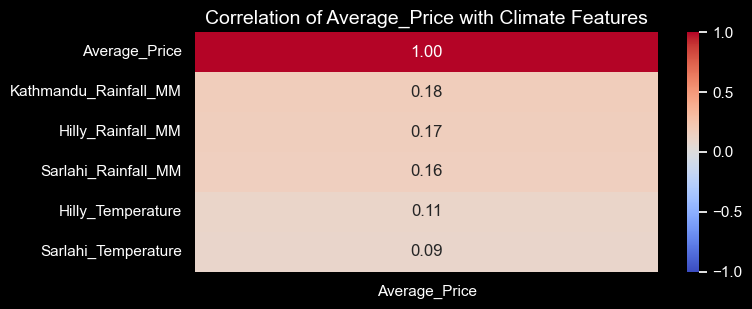

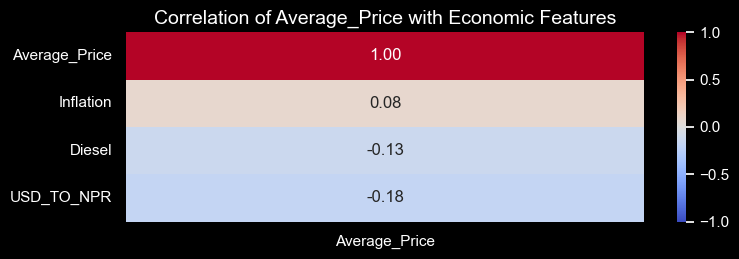

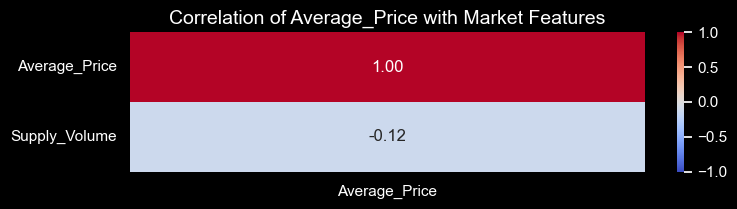

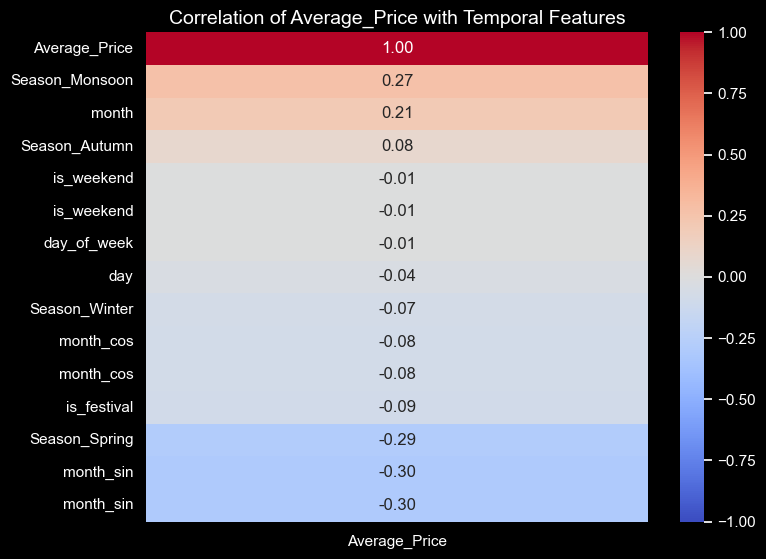

In [ ]:


# ============================================================
# ✅ Helper Function: Correlation Heatmap & Save Artifact
# ============================================================

def plot_and_save_corr(df, cols, title, save_dir="artifacts/eda/correlations"):
    os.makedirs(save_dir, exist_ok=True)
    
    subset = df[['Average_Price'] + cols].copy()
    corr = subset.corr(numeric_only=True)
    
    plt.figure(figsize=(8, len(cols) * 0.25 + 2))
    sns.heatmap(
        corr[['Average_Price']].sort_values(by='Average_Price', ascending=False),
        annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f"
    )
    plt.title(f'Correlation of Average_Price with {title} Features', fontsize=14)
    plt.tight_layout()

    # Save plot
    save_path = os.path.join(save_dir, f"corr_{title.lower()}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.plot()
    # plt.close()

    print(f"✅ Saved {title} correlation heatmap → {save_path}")

# ============================================================
# ✅ Generate and Save Correlation Plots
# ============================================================
for category_name, columns in col_categories.items():
    plot_and_save_corr(df, columns, category_name.replace('_cols', '').capitalize())


print("\n📊 All correlation heatmaps generated and saved.")


In [ ]:
# print(col_categories)

In [ ]:
print(col_categories_no_lag)

{'climate_cols': ['Kathmandu_Rainfall_MM', 'Hilly_Temperature', 'Hilly_Rainfall_MM', 'Sarlahi_Temperature', 'Sarlahi_Rainfall_MM'], 'economic_cols': ['USD_TO_NPR', 'Diesel', 'Inflation'], 'market_cols': ['Supply_Volume'], 'temporal_cols': ['is_festival', 'Season_Autumn', 'Season_Monsoon', 'Season_Spring', 'Season_Winter', 'is_weekend', 'month_sin', 'month_cos']}


In [ ]:
import joblib
# joblib.dump(col_categories, "col_categories_lag.joblib")
joblib.dump(col_categories_no_lag,"col_categories.joblib")

['col_categories.joblib']

In [ ]:
%%writefile DataCleaner.py

import os
import pandas as pd
import numpy as np


class DataCleanerLoader:
    """
    Handles raw data loading, cleaning, interpolation, 
    hilly feature generation, and final export to clean CSV.
    """

    def __init__(self,
                 input_path="data/raw_data.csv",
                 output_path="artifacts/data/predict_clean_data.csv",
                 date_col="Date",
                 target_col="Average_Price",
                 supply_col="Supply_Volume",
                 ):

        self.input_path = input_path
        self.output_path = output_path
        self.date_col = date_col
        self.target_col = target_col
        self.supply_col = supply_col

        # Default remove list if none provided
        self.remove_cols = remove_cols 

        os.makedirs(os.path.dirname(self.output_path), exist_ok=True)

    # -----------------------------
    # Load raw CSV
    # -----------------------------
    def load_raw(self):
        df = pd.read_csv(self.input_path)
        print(f"✅ Loaded raw data from {self.input_path} with shape {df.shape}")
        return df

    # -----------------------------
    # Basic formatting & cleanup
    # -----------------------------
    def basic_cleaning(self, df):
        df = df.copy()

        # Ensure proper date format and sorting
        if self.date_col in df.columns:
            df[self.date_col] = pd.to_datetime(df[self.date_col], errors="coerce")
            df = df.sort_values(self.date_col).reset_index(drop=True)

        # Drop obvious garbage columns
        drop_these = [c for c in self.remove_cols if c in df.columns]
        if drop_these:
            df = df.drop(columns=drop_these)
            print(f"🧹 Dropped specified columns: {drop_these}")

        # Convert boolean columns → int
        bool_cols = df.select_dtypes(include=["bool"]).columns
        if len(bool_cols) > 0:
            df[bool_cols] = df[bool_cols].astype(int)
            print(f"ℹ️ Converted boolean columns to int: {list(bool_cols)}")

        return df

    # -----------------------------
    # Interpolate supply volume
    # -----------------------------
    def interpolate_supply(self, df):
        if self.supply_col in df.columns:
            before_na = df[self.supply_col].isna().sum()
            df[self.supply_col] = df[self.supply_col].interpolate(method="linear", limit_direction="both")
            after_na = df[self.supply_col].isna().sum()
            print(f"📈 Interpolated '{self.supply_col}' — filled {before_na - after_na} missing values.")
        return df

    # -----------------------------
    # Create Hilly-region aggregate features
    # -----------------------------
    def add_hilly_features(self, df):
        """Create 'Hilly_Temperature' and 'Hilly_Rainfall_MM' 
        as averages across multiple hilly districts."""
        df = df.copy()

        hill_temp_cols = [c for c in df.columns if "Temperature" in c and "Hilly" not in c and "Kathmandu" not in c]
        hill_rain_cols = [c for c in df.columns if "Rainfall" in c and "Hilly" not in c and "Kathmandu" not in c]

        if hill_temp_cols:
            df["Hilly_Temperature"] = df[hill_temp_cols].mean(axis=1)
            print(f"🌡️ Created 'Hilly_Temperature' from: {hill_temp_cols}")

        if hill_rain_cols:
            df["Hilly_Rainfall_MM"] = df[hill_rain_cols].mean(axis=1)
            print(f"🌧️ Created 'Hilly_Rainfall_MM' from: {hill_rain_cols}")

        # remove individual hilly district columns now that aggregates exist
        redundant = hill_temp_cols + hill_rain_cols
        df = df.drop(columns=redundant, errors="ignore")

        return df

    # -----------------------------
    # Final cleanup (drop missing target, reset)
    # -----------------------------
    def finalize(self, df):
        if self.target_col in df.columns:
            before = len(df)
            df = df.dropna(subset=[self.target_col])
            after = len(df)
            print(f"🧭 Dropped {before - after} rows missing target '{self.target_col}'.")

        df = df.reset_index(drop=True)
        return df

    # -----------------------------
    # Full cleaning pipeline
    # -----------------------------
    def clean_and_save(self):
        df = self.load_raw()
        df = self.basic_cleaning(df)
        df = self.interpolate_supply(df)
        df = self.add_hilly_features(df)
        df = self.finalize(df)

        df.to_csv(self.output_path, index=False)
        print(f"✅ Cleaned data saved to {self.output_path} (shape={df.shape})")

        return df


Writing DataCleaner.py


In [ ]:
%%writefile AddLag.py


import pandas as pd
import numpy as np
import json
import os


class FeatureEngineer:
    def __init__(self,
                 lag_config_path="artifacts/configs/lag_config.json",
                 roll_config_path="artifacts/configs/roll_config.json"):
        self.lag_config_path = lag_config_path
        self.roll_config_path = roll_config_path
        self.lag_config = self._load_json(lag_config_path)
        self.roll_config = self._load_json(roll_config_path)

    def _load_json(self, path):
        if os.path.exists(path):
            with open(path, "r") as f:
                return json.load(f)
        else:
            print(f"⚠️ Config not found: {path}")
            return {}

    # -----------------------------
    # Apply lag features
    # -----------------------------
    def add_lag_features(self, df):
        df = df.copy()
        for col, lags in self.lag_config.items():
            if col not in df.columns:
                continue
            for lag in lags:
                df[f"{col}_lag{lag}"] = df[col].shift(lag)
        print(f"🕒 Added lag features for: {list(self.lag_config.keys())}")
        return df

    # -----------------------------
    # Apply rolling mean features
    # -----------------------------
    def add_rolling_features(self, df):
        df = df.copy()
        for col, windows in self.roll_config.items():
            if col not in df.columns:
                continue
            for w in windows:
                df[f"{col}_roll{w}"] = df[col].rolling(window=w).mean()
        print(f"📊 Added rolling features for: {list(self.roll_config.keys())}")
        return df

    # -----------------------------
    # Main method to apply all
    # -----------------------------
    def apply_features(self, df, use_lags=True):
        if not use_lags:
            print("🚫 Lag/Roll feature generation skipped.")
            return df

        df = self.add_lag_features(df)
        df = self.add_rolling_features(df)

        # drop rows with NaN after shifting
        df = df.dropna().reset_index(drop=True)
        print(f"✅ Lag/Roll features added. Final shape: {df.shape}")
        return df


Writing AddLag.py
